<a href="https://colab.research.google.com/github/smritishrestha821-jpg/Neural-Networ-Education-Diagram-To-Text/blob/main/finalCode_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip -q install transformers accelerate pillow tqdm matplotlib pandas
!pip -q install bitsandbytes


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 14.7 MB/s eta 0:00:00


In [ ]:
import os, glob, json, random, re
from collections import defaultdict, Counter
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from tqdm import tqdm

# ----------------------------
# IMPORTANT: Set your real root folder here (must exist)
# ----------------------------
DATA_ROOT = "/content/drive/MyDrive/NeuralNetwork/education5000"   # <-- change if your folder name is different
# Example: if your dataset is inside MyDrive/NN_Project/500 then set that exact path.

print("DATA_ROOT:", DATA_ROOT)

# Create expected subfolders if you want to organize (won't break if already exists)
os.makedirs(DATA_ROOT, exist_ok=True)

# Auto-find JSON / JSONL anywhere under DATA_ROOT (like 27jan searching inside sample_ folders)
json_files = glob.glob(os.path.join(DATA_ROOT, "**/*.json"), recursive=True)

# Auto-find images anywhere under DATA_ROOT
img_files = []
for ext in ["png","jpg","jpeg","webp","bmp"]:
    img_files.extend(glob.glob(os.path.join(DATA_ROOT, f"**/*.{ext}"), recursive=True))

print("\nFound JSON:", len(json_files))
print("Found images:", len(img_files))

print("\nExample JSON file:", json_files[0] if json_files else "None")
print("Example image file:", img_files[0] if img_files else "None")


DATA_ROOT: /content/drive/MyDrive/NeuralNetwork/education5000

Found JSON: 5798
Found images: 5798

Example JSON file: /content/drive/MyDrive/NeuralNetwork/education5000/sample_21752/data.json
Example image file: /content/drive/MyDrive/NeuralNetwork/education5000/sample_21752/image_1.png


In [ ]:
def load_json_any(fp):
    with open(fp, "r", encoding="utf-8") as f:
        return json.load(f)

def load_all_records(json_paths):
    records = []
    for fp in json_paths:
        try:
            obj = load_json_any(fp)
            if isinstance(obj, list):
                records.extend(obj)
            elif isinstance(obj, dict):
                # handle common nested patterns
                if "data" in obj and isinstance(obj["data"], list):
                    records.extend(obj["data"])
                elif "annotations" in obj and isinstance(obj["annotations"], list):
                    records.extend(obj["annotations"])
                else:
                    records.append(obj)
        except Exception as e:
            print("Failed:", fp, "|", e)
    return records

all_records = load_all_records(json_files)

print("Loaded JSON records:", len(all_records))

def norm(x):
    return "" if x is None else str(x).strip()

# Normalize keys (so EDA won’t crash)
clean = []
for r in all_records:
    if not isinstance(r, dict):
        continue
    rr = dict(r)
    rr["image_name"] = norm(rr.get("image_name") or rr.get("image") or rr.get("img") or rr.get("imageFile"))
    rr["question"]   = norm(rr.get("question") or rr.get("query") or rr.get("ques"))
    rr["answer"]     = norm(rr.get("answer") or rr.get("label") or rr.get("gt_answer"))
    rr["answer_id"]  = norm(rr.get("answer_id") or rr.get("answerId") or rr.get("correct_option"))
    rr["topic"]      = norm(rr.get("topic"))
    rr["knowledge"]  = norm(rr.get("knowledge"))
    rr["split"]      = norm(rr.get("split")).lower() or "train"
    clean.append(rr)

# Keep only usable rows
clean = [r for r in clean if r["image_name"] and r["question"]]
print("Usable records:", len(clean))


Loaded JSON records: 5798
Usable records: 5798


In [ ]:
import re

def _clean_text(s):
    s = "" if s is None else str(s)
    s = s.replace("\n", " ").strip()
    s = re.sub(r"\s+", " ", s)
    return s

def build_ground_truth_paragraph(item, max_qas=None):
    """
    Build FULL ground-truth explanation paragraph for ONE image using ALL its QAs.
    No truncation, no '...', and each sentence keeps question context.
    """
    topic = _clean_text(item.get("topic", ""))
    knowledge = _clean_text(item.get("knowledge", ""))

    # Intro (proposal-aligned)
    if knowledge and topic:
        intro = f"This diagram explains {knowledge} in {topic}."
    elif knowledge:
        intro = f"This diagram explains {knowledge}."
    elif topic:
        intro = f"This diagram explains a concept in {topic}."
    else:
        intro = "This diagram explains an educational concept."

    qas = item.get("qas", []) or []
    if max_qas is not None:
        qas = qas[:max_qas]  # set max_qas=None to include ALL

    sents = []
    seen = set()

    for r in qas:
        q = _clean_text(r.get("question", ""))
        a = _clean_text(r.get("answer", ""))
        if not q or not a:
            continue

        # Make every sentence meaningful even when True/False repeats
        if a.lower() in {"true", "false"}:
            sent = f"The statement '{q}' is {a}."
        else:
            sent = f"For the question '{q}', the correct answer is {a}."

        # Deduplicate exact repeats
        key = sent.lower().strip()
        if key in seen:
            continue
        seen.add(key)

        sents.append(sent)

    # If nothing found, return intro only (never crash)
    if not sents:
        return intro

    para = intro + " " + " ".join(sents)
    para = re.sub(r"\s+", " ", para).strip()
    return para


========== EDA (Proposal-aligned) ==========
Total QA records: 5798
Total unique images (image_name): 567
Images found under ROOT_TO_SCAN: 5798
Unique basenames indexed: 567

(a) QAs per image
Unique images: 567
Avg QAs per image: 10.225749559082892
Median QAs per image: 1.0
Max QAs per image: 5232


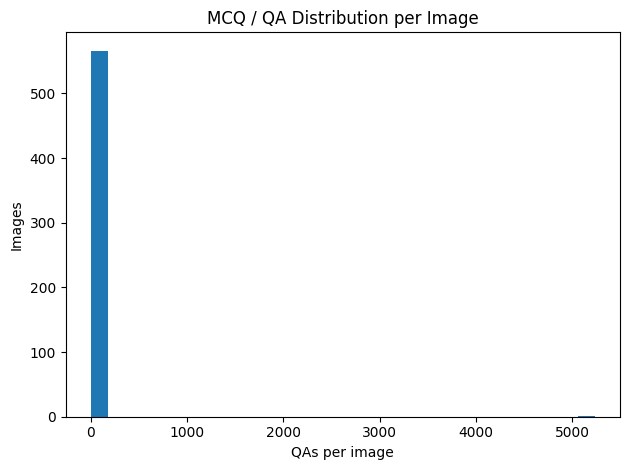


(b) Topic and knowledge coverage


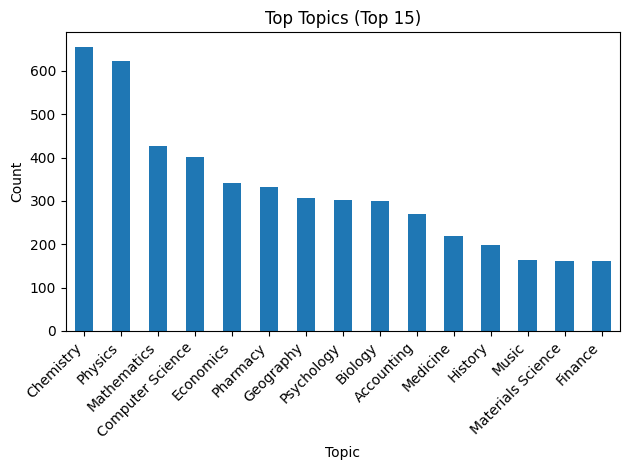

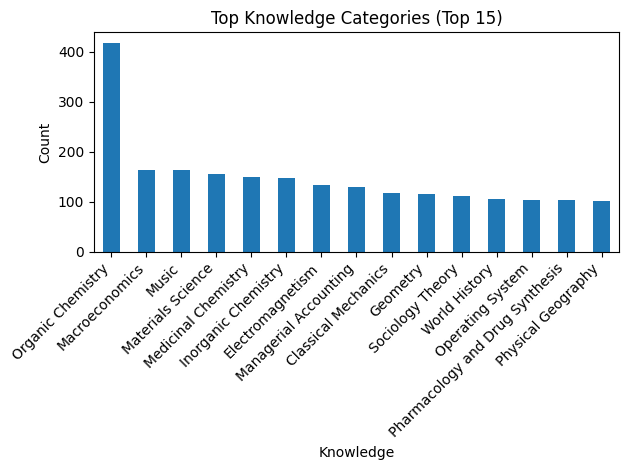


(c) Answer type distribution


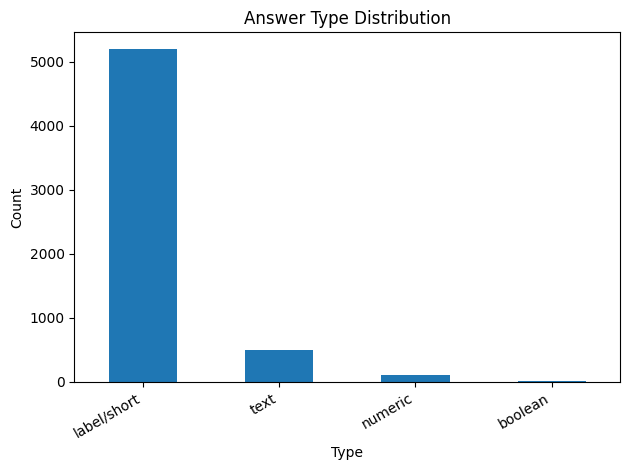

Answer type counts:
 _ans_expanded
label/short    5196
text            486
numeric          99
boolean          17
Name: count, dtype: int64

(d) Question length distribution


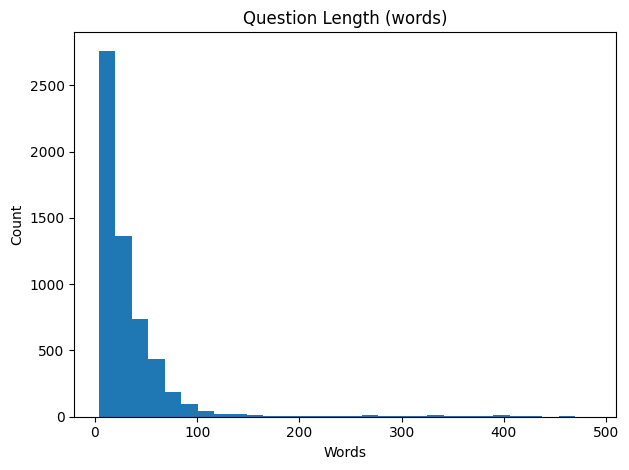

Question length stats:
  mean: 35.308382200758885
  median: 22.0
  max: 486

(e) Image–Text alignment qualitative samples

------------------------------------------------------------------------------------------
Image: social-science-economics-1307.png | split=train | topic=Economics | knowledge=Fiscal surpluses calculation | QAs=1


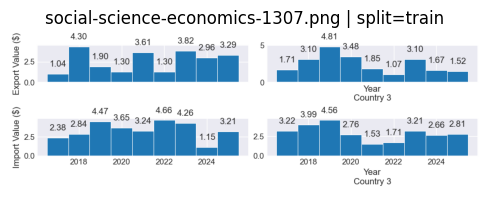


QA sample 1:
Question: In 2021, which countries records fiscal surpluses?
Answer: 2

Ground truth paragraph (auto-generated):
This diagram explains Fiscal surpluses calculation in Economics. For the question 'In 2021, which countries records fiscal surpluses?', the correct answer is 2.

------------------------------------------------------------------------------------------
Image: mathematics-algebra-4119.png | split=train | topic=Mathematics | knowledge=Elementary algebra | QAs=1


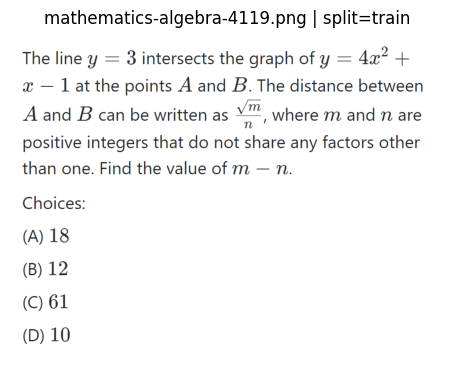


QA sample 1:
Question: Let's review the questions and assess if option D in the image is the appropriate solution for each of them.
Answer: False

Ground truth paragraph (auto-generated):
This diagram explains Elementary algebra in Mathematics. The statement 'Let's review the questions and assess if option D in the image is the appropriate solution for each of them.' is False.

------------------------------------------------------------------------------------------
Image: mathematics-geometry-5544.png | split=train | topic=Mathematics | knowledge=Length calculation | QAs=1


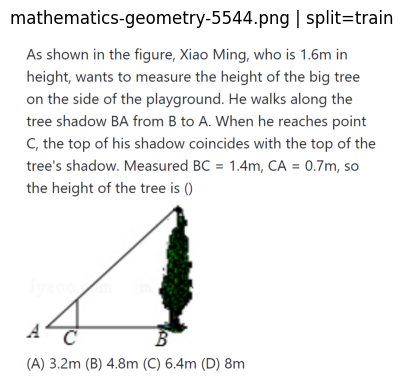


QA sample 1:
Question: Based on the information in the picture, can you determine the correct solution for the Geometry problem?
Answer: option B in the image is the correct answer.

Ground truth paragraph (auto-generated):
This diagram explains Length calculation in Mathematics. For the question 'Based on the information in the picture, can you determine the correct solution for the Geometry problem?', the correct answer is option B in the image is the correct answer..


In [ ]:
# =========================================
# CELL 4: EDA (Proposal-aligned) - SELF CONTAINED
# Requires: clean (list of dict records already loaded)
# Builds: df, records_by_image, image_items, img_index
# =========================================

import os, glob, random, re
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

# ---------------------------
# REQUIRED PATH
# ---------------------------
# Use the SAME root you used to load your dataset (Drive path).
# If you already have IMAGE_ROOT, set ROOT_TO_SCAN = IMAGE_ROOT, else DATA_ROOT.
ROOT_TO_SCAN = DATA_ROOT  # or IMAGE_ROOT if you have it

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ---------------------------
# 0) Build df from clean
# ---------------------------
df = pd.DataFrame(clean)
print("========== EDA (Proposal-aligned) ==========")
print("Total QA records:", len(clean))

if df.empty:
    raise ValueError("df is empty. 'clean' has no records. Load JSONs first.")

required_cols = ["image_name", "question", "answer"]
for c in required_cols:
    if c not in df.columns:
        raise ValueError(f"Missing required column '{c}'. Your clean records must contain it.")

print("Total unique images (image_name):", df["image_name"].nunique())

# ---------------------------
# 1) Build records_by_image + image_items
# ---------------------------
records_by_image = defaultdict(list)
for r in clean:
    img = r.get("image_name", "")
    if img:
        records_by_image[img].append(r)

def strict_split(recs):
    splits = {str(x.get("split","train")).lower().strip() for x in recs}
    if "test" in splits:
        return "test"
    if "val" in splits or "valid" in splits or "validation" in splits:
        return "val"
    return "train"

image_items = []
for img_name, recs in records_by_image.items():
    image_items.append({
        "image_name": img_name,
        "split": strict_split(recs),
        "topic": recs[0].get("topic",""),
        "knowledge": recs[0].get("knowledge",""),
        "qas": recs
    })

# ---------------------------
# 2) Build img_index (IMPORTANT: fixes your error)
# ---------------------------
img_index = {}
exts = ["png", "jpg", "jpeg", "webp", "bmp"]

# scan all images under ROOT_TO_SCAN
img_paths = []
for ext in exts:
    img_paths.extend(glob.glob(os.path.join(ROOT_TO_SCAN, f"**/*.{ext}"), recursive=True))

for p in img_paths:
    base = os.path.basename(p)
    # keep first found; if duplicates exist, first wins (fine for EDA)
    if base not in img_index:
        img_index[base] = p

print("Images found under ROOT_TO_SCAN:", len(img_paths))
print("Unique basenames indexed:", len(img_index))

# ---------------------------
# Helper functions
# ---------------------------
def normalize(x):
    return "" if x is None else str(x).strip()

def answer_expanded(r):
    # dataset already has full answer text usually
    ans = normalize(r.get("answer"))
    if ans:
        return ans

    # fallback: expand answer_id using choices if needed
    aid = normalize(r.get("answer_id")).lower()
    choices = r.get("choices", {})
    if isinstance(choices, dict) and aid in choices:
        return normalize(choices[aid])
    return ""

def answer_type(a: str):
    a = normalize(a)
    if a.lower() in {"true", "false"}:
        return "boolean"
    if re.fullmatch(r"\d+(\.\d+)?", a):
        return "numeric"
    if re.fullmatch(r"[A-Za-z]{1,3}", a) or len(a) <= 2:
        return "label/short"
    return "text"

def show_image_by_name(image_name):
    p = img_index.get(image_name, None)
    if p is None:
        return None
    try:
        return Image.open(p).convert("RGB")
    except:
        return None

# ---------------------------
# (a) MCQ distribution per image
# ---------------------------
qa_per_img = df.groupby("image_name").size()
print("\n(a) QAs per image")
print("Unique images:", df["image_name"].nunique())
print("Avg QAs per image:", float(qa_per_img.mean()))
print("Median QAs per image:", float(qa_per_img.median()))
print("Max QAs per image:", int(qa_per_img.max()))

plt.figure()
plt.hist(qa_per_img, bins=30)
plt.title("MCQ / QA Distribution per Image")
plt.xlabel("QAs per image")
plt.ylabel("Images")
plt.tight_layout()
plt.show()

# ---------------------------
# (b) Topic and knowledge coverage
# ---------------------------
print("\n(b) Topic and knowledge coverage")

if "topic" in df.columns:
    topic_counts = df["topic"].replace("", "Unknown").fillna("Unknown").value_counts().head(15)
    plt.figure()
    topic_counts.plot(kind="bar")
    plt.title("Top Topics (Top 15)")
    plt.xlabel("Topic")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("[WARN] topic column not found")

if "knowledge" in df.columns:
    knowledge_counts = df["knowledge"].replace("", "Unknown").fillna("Unknown").value_counts().head(15)
    plt.figure()
    knowledge_counts.plot(kind="bar")
    plt.title("Top Knowledge Categories (Top 15)")
    plt.xlabel("Knowledge")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("[WARN] knowledge column not found")

# ---------------------------
# (c) Answer type distribution
# ---------------------------
print("\n(c) Answer type distribution")

df["_ans_expanded"] = df.apply(lambda r: answer_expanded(r.to_dict()), axis=1)
atype = df["_ans_expanded"].map(answer_type).value_counts()

plt.figure()
atype.plot(kind="bar")
plt.title("Answer Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("Answer type counts:\n", atype)

# ---------------------------
# (d) Question length analysis
# ---------------------------
print("\n(d) Question length distribution")

q_len = df["question"].fillna("").map(lambda x: len(str(x).split()))
plt.figure()
plt.hist(q_len, bins=30)
plt.title("Question Length (words)")
plt.xlabel("Words")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("Question length stats:")
print("  mean:", float(q_len.mean()))
print("  median:", float(q_len.median()))
print("  max:", int(q_len.max()))

# ---------------------------
# (e) Image–Text alignment qualitative check
# ---------------------------
print("\n(e) Image–Text alignment qualitative samples")

df_img = pd.DataFrame([{
    "image_name": it["image_name"],
    "split": it.get("split", "train"),
    "topic": it.get("topic", ""),
    "knowledge": it.get("knowledge", ""),
    "n_qas": len(it.get("qas", []))
} for it in image_items])

n_show = min(3, len(df_img))
sample_imgs = df_img.sample(n=n_show, random_state=SEED) if n_show > 0 else df_img

for _, row in sample_imgs.iterrows():
    img_name = row["image_name"]
    img = show_image_by_name(img_name)

    print("\n" + "-"*90)
    print(f"Image: {img_name} | split={row['split']} | topic={row['topic']} | knowledge={row['knowledge']} | QAs={row['n_qas']}")

    if img is not None:
        plt.figure(figsize=(5,4))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{img_name} | split={row['split']}")
        plt.tight_layout()
        plt.show()
    else:
        print("[WARN] image not found under ROOT_TO_SCAN for:", img_name)

    qas = records_by_image.get(img_name, [])
    if qas:
        pick = random.sample(qas, k=min(2, len(qas)))
        for j, rr in enumerate(pick, start=1):
            print(f"\nQA sample {j}:")
            print("Question:", rr.get("question",""))
            print("Answer:", rr.get("answer",""))

    # Ground-truth paragraph (auto-generated) — safe
    item_match = next((it for it in image_items if it["image_name"] == img_name), None)
    if item_match:
        try:
            gt_para = build_ground_truth_paragraph(item_match, max_qas=8)
            print("\nGround truth paragraph (auto-generated):")
            print(gt_para)
        except Exception as e:
            print("[WARN] build_ground_truth_paragraph failed:", e)
    else:
        print("[WARN] image item not found for:", img_name)


In [ ]:
records_by_image = defaultdict(list)
for r in clean:
    records_by_image[r["image_name"]].append(r)

def majority_split(recs):
    c = Counter([x.get("split","train") for x in recs])
    return c.most_common(1)[0][0]

image_items = []
for img_name, recs in records_by_image.items():
    sp = majority_split(recs)
    image_items.append({
        "image_name": img_name,
        "split": sp,
        "topic": recs[0].get("topic",""),
        "knowledge": recs[0].get("knowledge",""),
        "qas": recs
    })

train_items = [x for x in image_items if x["split"] == "train"]
val_items   = [x for x in image_items if x["split"] in ["val","valid","validation"]]
test_items  = [x for x in image_items if x["split"] == "test"]

print("Image-level samples:", len(image_items))
print("Train:", len(train_items), "Val:", len(val_items), "Test:", len(test_items))


Image-level samples: 567
Train: 390 Val: 20 Test: 157


In [ ]:
import re

# ----------------------------
# Property-aware sentence builder
# ----------------------------

_BOOL_TRUE = {"true", "t", "yes"}
_BOOL_FALSE = {"false", "f", "no"}

def _norm(s):
    return "" if s is None else str(s).strip()

def _is_true(a):  return _norm(a).lower() in _BOOL_TRUE
def _is_false(a): return _norm(a).lower() in _BOOL_FALSE

# Extract a clean "statement" from questions like:
# "Please judge whether XXX is correct."
_stmt_re = re.compile(r"please\s+judge\s+whether\s+(.*?)(?:\s+is\s+correct\.?\s*)?$", re.I)

def _extract_statement(q: str) -> str:
    q = _norm(q)
    q_clean = q.strip().rstrip("?").rstrip("؟").strip()
    m = _stmt_re.match(q_clean.lower())
    if m:
        # use original casing slice (approx) by re-running on original
        m2 = _stmt_re.match(q_clean)
        stmt = (m2.group(1) if m2 else m.group(1)).strip()
        # remove trailing punctuation
        stmt = stmt.rstrip(".").strip()
        return stmt
    return q_clean

# Assign priority so summary is ordered and readable
def _property_priority(q_lower: str) -> int:
    # lower number = earlier in paragraph
    if "full binary tree" in q_lower or "complete binary tree" in q_lower:
        return 10  # structure
    if "child" in q_lower or "parent" in q_lower or "left child" in q_lower or "right child" in q_lower:
        return 20  # relationships
    if "depth" in q_lower or "height" in q_lower:
        return 30  # measurements
    if "logic" in q_lower or "circuit" in q_lower or "gate" in q_lower:
        return 40  # logic circuits
    return 50      # fallback

# Main: question + answer -> property-aware sentence
def qa_to_sentence(q: str, a: str) -> str:
    q_raw = _norm(q)
    a_raw = _norm(a)
    ql = q_raw.lower()

    # ---- Binary tree specific ----
    if "binary tree" in ql or "tree" in ql:
        # depth
        if "depth" in ql:
            return f"The depth of the binary tree shown in the diagram is {a_raw}."

        # full binary tree (often asked as "not a full binary tree")
        if "full binary tree" in ql:
            stmt = _extract_statement(q_raw)  # e.g., "this binary tree is not a full binary tree"
            if _is_true(a_raw):
                # statement is correct
                return f"The diagram shows that {stmt}."
            if _is_false(a_raw):
                # statement is incorrect -> negate statement safely
                # If statement already includes "not", remove it. Else add "not".
                stmt_low = stmt.lower()
                if "not " in stmt_low:
                    stmt_fixed = re.sub(r"\bnot\s+", "", stmt, flags=re.I).strip()
                    return f"The diagram shows that {stmt_fixed}."
                else:
                    return f"The diagram shows that {stmt} is not correct."
            # non-boolean fallback
            return f"For the property about full binary tree, the answer is {a_raw}."

        # complete binary tree (often asked after deletion)
        if "complete binary tree" in ql:
            stmt = _extract_statement(q_raw)  # e.g., "after deleting the three nodes, the tree may be a complete binary tree"
            if _is_true(a_raw):
                return f"The diagram indicates that {stmt}."
            if _is_false(a_raw):
                # Prefer clearer: "does not become complete"
                # If "may be" appears, rewrite
                stmt2 = stmt
                stmt2 = re.sub(r"\bmay\s+be\b", "does not become", stmt2, flags=re.I).strip()
                # If rewrite didn't change much, use generic "is incorrect"
                if stmt2.lower() == stmt.lower():
                    return f"The diagram shows that {stmt} is not correct."
                return f"The diagram shows that {stmt2}."
            return f"For the property about complete binary tree, the answer is {a_raw}."

        # child / node relation questions
        if "left child" in ql or "right child" in ql:
            # Try to capture "node X"
            m = re.search(r"\bnode\s*([0-9]+)\b", ql)
            node = m.group(1) if m else None

            stmt = _extract_statement(q_raw)
            # Examples:
            # "Which is the left child node of the right child node of the node 4"
            if node and ("left child" in ql and "right child" in ql):
                if a_raw.lower() in {"none", "null"}:
                    return f"The diagram shows that the left child of the right child of node {node} does not exist."
                return f"The left child of the right child of node {node} is node {a_raw}."
            # fallback generic for other child questions
            if a_raw.lower() in {"none", "null"}:
                return f"According to the diagram, the requested child node does not exist."
            return f"According to the diagram, the answer to '{stmt}' is {a_raw}."

    # ---- Logic circuit specific ----
    if "logic" in ql or "circuit" in ql or "gate" in ql:
        stmt = _extract_statement(q_raw)
        if _is_true(a_raw) or _is_false(a_raw):
            return f"Based on the logic circuit shown, the statement '{stmt}' is {a_raw}."
        return f"Based on the logic circuit diagram, the answer is {a_raw}."

    # ---- Generic True/False sentence with property clause ----
    if _is_true(a_raw) or _is_false(a_raw):
        stmt = _extract_statement(q_raw)
        return f"The diagram indicates that the statement '{stmt}' is {a_raw}."

    # ---- Generic what/which/how many ----
    if ql.startswith("how many"):
        return f"The diagram indicates the correct number is {a_raw}."
    if ql.startswith("what"):
        return f"The diagram indicates that {a_raw} is the correct answer."
    if ql.startswith("which"):
        return f"The diagram identifies {a_raw} as the correct answer."

    # Fallback
    return f"For the question '{_extract_statement(q_raw)}', the correct answer is {a_raw}."


In [ ]:
import torch
from transformers import AutoProcessor, Blip2ForConditionalGeneration

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# If you don't want to login, you can pass token=None and only public models will work.
# But your error is 401, so better to login once.
HF_TOKEN = None  # optional: paste token string here if you want hardcode (not recommended)

# Model candidates (try in order)
MODEL_CANDIDATES = [
    "Salesforce/blip2-flan-t5-base",
    "Salesforce/blip2-flan-t5-xl",
    "Salesforce/blip2-opt-2.7b",
]

processor, model = None, None
last_err = None

for name in MODEL_CANDIDATES:
    try:
        print("Trying model:", name)
        processor = AutoProcessor.from_pretrained(name, token=HF_TOKEN)
        if DEVICE == "cuda":
            model = Blip2ForConditionalGeneration.from_pretrained(
                name,
                load_in_8bit=True,
                device_map="auto",
                token=HF_TOKEN
            )
        else:
            model = Blip2ForConditionalGeneration.from_pretrained(name, token=HF_TOKEN).to(DEVICE)
        MODEL_NAME = name
        print("Loaded:", name)
        break
    except Exception as e:
        last_err = e
        print("Failed:", name, "|", type(e).__name__, e)

if model is None:
    raise RuntimeError(f"Could not load any BLIP-2 model. Last error: {last_err}")

# Freeze vision + language model, train Q-Former (+ projection)
for p in model.vision_model.parameters():
    p.requires_grad = False
if hasattr(model, "language_model"):
    for p in model.language_model.parameters():
        p.requires_grad = False
for p in model.qformer.parameters():
    p.requires_grad = True
if hasattr(model, "language_projection"):
    for p in model.language_projection.parameters():
        p.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / Total: {total:,}")


DEVICE: cpu
Trying model: Salesforce/blip2-flan-t5-base
Failed: Salesforce/blip2-flan-t5-base | OSError Salesforce/blip2-flan-t5-base is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`
Trying model: Salesforce/blip2-flan-t5-xl


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/5.81G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.96G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

Loaded: Salesforce/blip2-flan-t5-xl
Trainable params: 106,737,152 / Total: 3,942,446,592


In [ ]:
def find_image_path(image_name):
    # fast exact match search in discovered list
    # build index once
    return None

# Build an index for fast lookup (important)
img_index = {}
for p in img_files:
    img_index[os.path.basename(p)] = p

def get_image_path(image_name):
    return img_index.get(image_name, None)

def build_prompt(item):
    topic = (item.get("topic","") or "").strip()
    knowledge = (item.get("knowledge","") or "").strip()
    return (
        "Generate a concise educational explanation of the diagram.\n"
        "IMPORTANT: Explain what is visible in the diagram (labels, numbers, arrows, operations).\n"
        "Do NOT give only a general definition.\n\n"
        f"Knowledge: {knowledge}\n"
        f"Topic: {topic}\n\n"
        "Write 3–6 clear sentences in simple English."
    )


class ExplainDataset(Dataset):
    def __init__(self, items, max_qas=8):
        self.items = items
        self.max_qas = max_qas

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]
        img_path = get_image_path(item["image_name"])
        if img_path is None:
            return None

        image = Image.open(img_path).convert("RGB")
        prompt = build_prompt(item)
        target = build_ground_truth_paragraph(item, max_qas=self.max_qas)

        # reference question only for RANDOM TEST printing
        ref_q = random.choice(item["qas"])["question"] if item["qas"] else ""
        return {"image": image, "prompt": prompt, "target": target,
                "image_name": item["image_name"], "ref_question": ref_q}

def collate_fn(batch):
    batch = [b for b in batch if b is not None]
    return batch if batch else None

EPOCHS = 5
BATCH_SIZE = 2
LR = 1e-5
WEIGHT_DECAY = 0.01
MAX_NEW_TOKENS = 40

train_ds = ExplainDataset(train_items, max_qas=8)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

optimizer = AdamW([p for p in model.parameters() if p.requires_grad], lr=LR, weight_decay=WEIGHT_DECAY)

def batch_to_inputs(batch):
    images = [x["image"] for x in batch]
    prompts = [x["prompt"] for x in batch]
    targets = [x["target"] for x in batch]

    # Encode image + prompt
    inputs = processor(images=images, text=prompts, return_tensors="pt", padding=True).to(DEVICE)

    # Encode targets using the underlying tokenizer (BLIP-2 uses a text tokenizer internally)
    tok = processor.tokenizer(
        targets,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=256
    )

    labels = tok.input_ids.to(DEVICE)

    # Ignore pad tokens in loss
    pad_id = processor.tokenizer.pad_token_id
    if pad_id is not None:
        labels[labels == pad_id] = -100

    inputs["labels"] = labels
    return inputs




RANDOM TEST #1

Topic: Cognitive Science
Knowledge: Science
Image Name: social-science-cognitive-science-198.png
Random Question: What does the image represent?



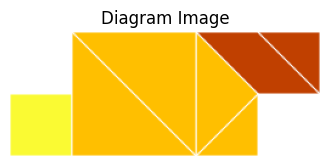


MODEL OUTPUT:
The diagram shows the n-dimensional space of the n-dimensional n-dimensional n-dimensional n-dimensional n-dimensional n-dimensional n-dimensional 

Summary of the Topic:
This diagram explains Science in Cognitive Science.
For the question 'What does the image represent?', the correct answer is Snail.

RANDOM TEST #2

Topic: Geography
Knowledge: Depth & direction analysis
Image Name: social-science-geography-3016.png
Random Question: What is the westernmost point's depth?



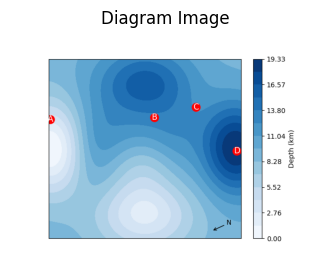


MODEL OUTPUT:
The diagram shows the location of the ice sheet and the direction of the flow 

Summary of the Topic:
This diagram explains Depth & direction analysis in Geography.
For the question 'What is the westernmost point's depth?', the correct answer is 19.3 km.

RANDOM TEST #3

Topic: Mathematics
Knowledge: Event ordering
Image Name: commonsense-temporal-commonsense-2470.png
Random Question: Look at the following schedule. When does hockey practice begin?



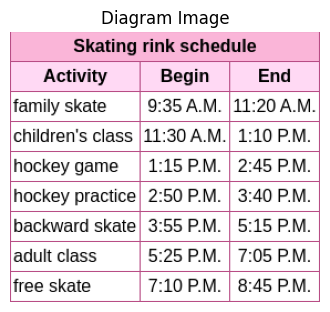


MODEL OUTPUT:
The diagram shows the events in the order of the day, the week, and the month. 

Summary of the Topic:
This diagram explains Event ordering in Mathematics.
For the question 'Look at the following schedule.
When does hockey practice begin?', the correct answer is 2:50 PM.


In [ ]:
from IPython.display import display
import matplotlib.pyplot as plt
model.eval()

def generate_explanation(item):
    img_path = get_image_path(item["image_name"])
    image = Image.open(img_path).convert("RGB")
    prompt = build_prompt(item)

    inputs = processor(images=image, text=prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out_ids = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)
    pred = processor.decode(out_ids[0], skip_special_tokens=True).strip()
    return pred

pool = test_items if len(test_items) > 0 else train_items

for i in range(1, 4):
    item = random.choice(pool)

    img_path = get_image_path(item["image_name"])
    image = Image.open(img_path).convert("RGB")

    pred = generate_explanation(item)
    gt = build_ground_truth_paragraph(item, max_qas=None)  # include ALL QAs
    ref_q = random.choice(item["qas"])["question"] if item["qas"] else ""

    print(f"\nRANDOM TEST #{i}\n")
    print(f"Topic: {item.get('topic','')}")
    print(f"Knowledge: {item.get('knowledge','')}")
    print(f"Image Name: {item['image_name']}")
    print(f"Random Question: {ref_q}\n")

    # ✅ SHOW IMAGE
    plt.figure(figsize=(4,4))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Diagram Image")
    display(plt.gcf())
    plt.close()

    print("\nMODEL OUTPUT:")
    print(pred, "\n")

    print("Summary of the Topic:")
    print(gt.replace(". ", ".\n"))
